In [ ]:
# !pip install openpyxl
# !pip install pandas
# !pip install keras-tuner

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.models import Sequential, Model, load_model
from keras.layers import Reshape, Dense, Input
from sklearn.model_selection import train_test_split
import keras_tuner as kt
from keras.utils import plot_model
import pandas as pd


I0000 00:00:1782563809.940756  657321 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782563810.029050  657321 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782563812.763575  657321 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
data_folder = "/home/sputnik/main/MyFolder/DL_Practice/prob1_data" 
output_file = data_folder + "/output.xlsx"
stress_folder = data_folder + "/stress"



In [3]:
X_df = pd.read_excel(output_file, header=None)

X_df = X_df.dropna(axis=0, how="all")
X_df = X_df.dropna(axis=1, how="all")

X = X_df.values.astype(float)

print("Shape of X:", X.shape)


Shape of X: (5000, 226)


In [4]:
num_samples = X.shape[0]

y = []

for i in range(num_samples):
    stress_file = stress_folder + "/stress_" + str(i) + ".txt"
    
    stress_data = np.loadtxt(stress_file)
    
    von_mises_stress = stress_data[:, 0]
    max_stress = np.max(von_mises_stress)
    
    y.append(max_stress)

y = np.array(y).reshape(-1, 1)

print("Shape of y:", y.shape)
print("Minimum max stress:", np.min(y))
print("Maximum max stress:", np.max(y))
print("Mean max stress:", np.mean(y))


Shape of y: (5000, 1)
Minimum max stress: 4412533.22285112
Maximum max stress: 43744146.8480609
Mean max stress: 9497545.137606278


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (4000, 226)
X_test: (1000, 226)
y_train: (4000, 1)
y_test: (1000, 1)


In [6]:
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)
X_std[X_std == 0] = 1

y_mean = np.mean(y_train, axis=0)
y_std = np.std(y_train, axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std


In [7]:
def r2metric(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())


In [8]:
tf.keras.backend.clear_session()

model1 = Sequential()

model1.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],),
                 kernel_initializer=keras.initializers.HeNormal()))
model1.add(layers.Dropout(0.1))
model1.add(Dense(64, activation='relu',
                 kernel_initializer=keras.initializers.HeNormal()))
model1.add(layers.Dropout(0.1))
model1.add(Dense(16, activation='relu',
                 kernel_initializer=keras.initializers.HeNormal()))

model1.add(Dense(1, name="Output"))

model1.summary()


/home/sputnik/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1782563901.740173  657321 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        14,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,745 (77.13 KB)

 Trainable params: 19,745 (77.13 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=[r2metric, 'mape']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

history = model1.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.2284 - mape: 513.5063 - r2metric: -0.8916 - val_loss: 0.8886 - val_mape: 240.6519 - val_r2metric: -0.0422
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7977 - mape: 293.4571 - r2metric: -0.0031 - val_loss: 0.7613 - val_mape: 240.9384 - val_r2metric: 0.1414
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6291 - mape: 312.5747 - r2metric: 0.1978 - val_loss: 0.6505 - val_mape: 235.0628 - val_r2metric: 0.2964
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4663 - mape: 317.6595 - r2metric: 0.3945 - val_loss: 0.5506 - val_mape: 305.3929 - val_r2metric: 0.3275
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3734 - mape: 332.3583 - r2metric: 0.5048 - val_loss: 0.5133 - val_mape: 274.5494 - val_r2metric: 0.4042
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3073 - mape: 253.0628 - r2metric: 0.5618 - val_loss: 0.5194 - val_mape: 187.4975 - val_r2metric: 0.

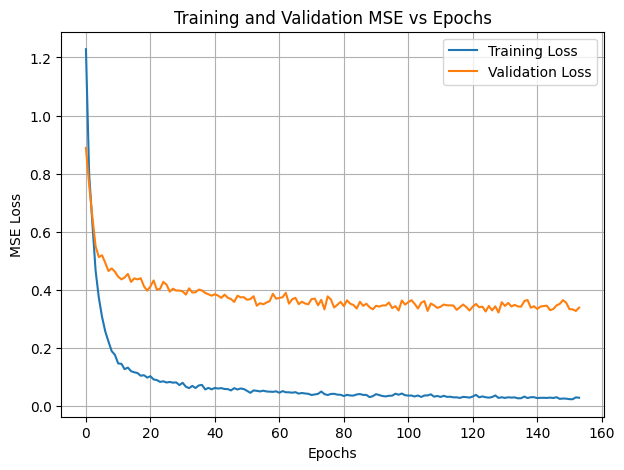

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation MSE vs Epochs")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
test_loss, test_r2, test_mape = model1.evaluate(
    X_test_scaled, y_test_scaled, verbose=0
)

print("Testing MSE on scaled data:", test_loss)
print("Testing R2 score:", test_r2)
print("Testing MAPE on scaled data:", test_mape)


Testing MSE on scaled data: 0.26971402764320374
Testing R2 score: 0.6564923524856567
Testing MAPE on scaled data: 144.48841857910156


In [12]:
y_test_pred_scaled = model1.predict(X_test_scaled, verbose=0)

y_test_pred = y_test_pred_scaled * y_std + y_mean

mse_actual = np.mean((y_test - y_test_pred)**2)
mape_actual = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

ss_res = np.sum((y_test - y_test_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_actual = 1 - ss_res / ss_tot

print("Testing MSE in actual stress scale:", mse_actual)
print("Testing MAPE (%):", mape_actual)
print("Testing R2 score:", r2_actual)


Testing MSE in actual stress scale: 4385080251573.263
Testing MAPE (%): 11.806229243980649
Testing R2 score: 0.6702589731407749


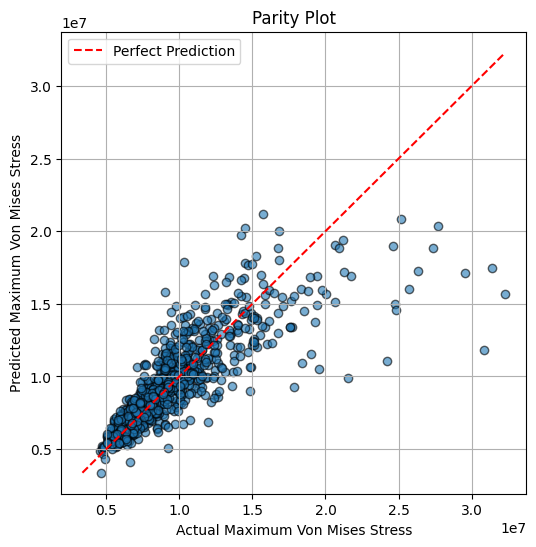

In [13]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolor="black")

min_val = min(np.min(y_test), np.min(y_test_pred))
max_val = max(np.max(y_test), np.max(y_test_pred))

plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction")

plt.xlabel("Actual Maximum Von Mises Stress")
plt.ylabel("Predicted Maximum Von Mises Stress")
plt.title("Parity Plot")
plt.legend()
plt.grid(True)
plt.show()


In [70]:
num_design_variables = X_train.shape[1]

# Physical thickness bounds from training data
x_min = np.min(X_train, axis=0).reshape(1, -1).astype(np.float32)
x_max = np.max(X_train, axis=0).reshape(1, -1).astype(np.float32)

x_range = x_max - x_min
x_range[x_range == 0] = 1.0

# Normalized volume fraction target
VF_target = 0.5

# Optimization settings
eta = 0.005
N = 1000
tolerance = 1e-5

# Penalty to prevent surrogate from predicting below FEM range
lambda_low_stress = 1000.0
y_min_physical = np.min(y_train)

print("Number of design variables:", num_design_variables)
print("Target normalized volume fraction:", VF_target)
print("Minimum FEM training stress:", y_min_physical)


Number of design variables: 226
Target normalized volume fraction: 0.5
Minimum FEM training stress: 4412533.22285112


In [71]:
# Initialize normalized design at target volume fraction
z_init = VF_target * np.ones((1, num_design_variables), dtype=np.float32)
z = tf.Variable(z_init, dtype=tf.float32)

X_mean_tf = tf.constant(X_mean.reshape(1, -1), dtype=tf.float32)
X_std_tf = tf.constant(X_std.reshape(1, -1), dtype=tf.float32)

y_mean_tf = tf.constant(y_mean.reshape(1, -1), dtype=tf.float32)
y_std_tf = tf.constant(y_std.reshape(1, -1), dtype=tf.float32)

x_min_tf = tf.constant(x_min, dtype=tf.float32)
x_range_tf = tf.constant(x_range, dtype=tf.float32)

y_min_tf = tf.constant(y_min_physical, dtype=tf.float32)

print("Initial normalized volume fraction:", tf.reduce_mean(z).numpy())


Initial normalized volume fraction: 0.5


In [72]:
rows = 14
cols = 17

map_size = rows * cols
pad_len = map_size - num_design_variables

# Mask handles the padded unused cells
mask_np = np.zeros((map_size,), dtype=np.float32)
mask_np[:num_design_variables] = 1.0
mask_np = mask_np.reshape(1, rows, cols, 1)

mask_tf = tf.constant(mask_np, dtype=tf.float32)

# 3x3 spatial averaging kernel
kernel_np = np.ones((3, 3, 1, 1), dtype=np.float32)
kernel_tf = tf.constant(kernel_np, dtype=tf.float32)

def spatial_gradient_filter(g):
    # g shape: (1, 226)
    g_flat = tf.reshape(g, [-1])
    
    # Pad to pseudo-grid size
    g_padded = tf.pad(g_flat, [[0, pad_len]])
    g_grid = tf.reshape(g_padded, [1, rows, cols, 1])
    
    # Ignore padded cells using mask
    g_grid = g_grid * mask_tf
    
    # Sum neighboring gradients
    neighbor_sum = tf.nn.conv2d(
        g_grid,
        kernel_tf,
        strides=1,
        padding="SAME"
    )
    
    # Count valid neighboring cells
    neighbor_count = tf.nn.conv2d(
        mask_tf,
        kernel_tf,
        strides=1,
        padding="SAME"
    )
    
    # Average only over valid cells
    g_filtered_grid = neighbor_sum / (neighbor_count + 1e-8)
    
    # Convert back to 226 variables
    g_filtered_flat = tf.reshape(g_filtered_grid, [-1])
    g_filtered = g_filtered_flat[:num_design_variables]
    
    return tf.reshape(g_filtered, [1, num_design_variables])


In [73]:
x_initial = x_min_tf + z * x_range_tf
x_initial_scaled = (x_initial - X_mean_tf) / X_std_tf

initial_stress_scaled = model1(x_initial_scaled)
initial_stress = initial_stress_scaled * y_std_tf + y_mean_tf

print("Initial predicted stress:", initial_stress.numpy()[0][0])
print("Initial normalized volume fraction:", tf.reduce_mean(z).numpy())


Initial predicted stress: 8339173.5
Initial normalized volume fraction: 0.5


In [74]:
stress_history = []
volume_history = []

previous_stress = None

for k in range(N):
    
    with tf.GradientTape() as tape:
        tape.watch(z)
        
        # Convert normalized design z to physical thickness x
        x_physical = x_min_tf + z * x_range_tf
        
        # Scale physical design before NN prediction
        x_scaled = (x_physical - X_mean_tf) / X_std_tf
        
        # Predict max Von Mises stress
        sigma_scaled = model1(x_scaled)
        sigma = sigma_scaled * y_std_tf + y_mean_tf
        
        # Penalty if surrogate predicts below physically observed FEM minimum
        low_stress_penalty = tf.square(tf.nn.relu(y_min_tf - sigma[0, 0]))
        
        # Objective
        J = sigma[0, 0] + lambda_low_stress * low_stress_penalty
    
    # Raw gradient dJ/dz
    g_raw = tape.gradient(J, z)
    
    # Spatial gradient filtering
    g_filtered = spatial_gradient_filter(g_raw)
    
    # Normalize filtered gradient for stable update
    g_filtered = g_filtered / (tf.reduce_max(tf.abs(g_filtered)) + 1e-8)
    
    # Gradient descent update
    z_new = z - eta * g_filtered
    
    # Bounds in normalized design space
    z_new = tf.clip_by_value(z_new, 0.0, 1.0)
    
    # Enforce constant volume fraction
    z_new = z_new * (VF_target / tf.reduce_mean(z_new))
    
    # Clip again after scaling
    z_new = tf.clip_by_value(z_new, 0.0, 1.0)
    
    # Re-enforce volume fraction approximately
    z_new = z_new * (VF_target / tf.reduce_mean(z_new))
    z_new = tf.clip_by_value(z_new, 0.0, 1.0)
    
    z.assign(z_new)
    
    current_stress = sigma.numpy()[0][0]
    current_vf = tf.reduce_mean(z).numpy()
    
    stress_history.append(current_stress)
    volume_history.append(current_vf)
    
    if k % 50 == 0:
        print("Iteration:", k)
        print("Predicted stress:", current_stress)
        print("Normalized volume fraction:", current_vf)
        print()
    
    if previous_stress is not None:
        if abs(previous_stress - current_stress) < tolerance:
            print("Converged at iteration:", k)
            break
    
    previous_stress = current_stress


Iteration: 0
Predicted stress: 8339173.5
Normalized volume fraction: 0.49999994



Iteration: 50
Predicted stress: 7127060.0
Normalized volume fraction: 0.49999997

Iteration: 100
Predicted stress: 5827112.0
Normalized volume fraction: 0.5

Iteration: 150
Predicted stress: 5068327.5
Normalized volume fraction: 0.50000006

Iteration: 200
Predicted stress: 4509006.5
Normalized volume fraction: 0.5

Iteration: 250
Predicted stress: 4403946.0
Normalized volume fraction: 0.5

Iteration: 300
Predicted stress: 4404370.5
Normalized volume fraction: 0.49999994

Iteration: 350
Predicted stress: 4404789.5
Normalized volume fraction: 0.5

Iteration: 400
Predicted stress: 4405209.5
Normalized volume fraction: 0.50000006

Iteration: 450
Predicted stress: 4405631.0
Normalized volume fraction: 0.5

Iteration: 500
Predicted stress: 4406050.5
Normalized volume fraction: 0.5

Iteration: 550
Predicted stress: 4406472.0
Normalized volume fraction: 0.5

Iteration: 600
Predicted stress: 4406887.5
Normalized volume fraction: 0.5

Iteration: 650
Predicted stress: 4407308.0
Normalized volume 

In [75]:
z_optimized = z.numpy()

x_optimized = x_min + z_optimized * x_range

x_optimized_scaled = (x_optimized - X_mean) / X_std

optimized_stress_scaled = model1.predict(x_optimized_scaled, verbose=0)
optimized_stress = optimized_stress_scaled * y_std + y_mean

initial_stress_value = initial_stress.numpy()[0][0]
optimized_stress_value = optimized_stress[0][0]

reduction = (
    (initial_stress_value - optimized_stress_value)
    / initial_stress_value
) * 100

print("Initial predicted stress:", initial_stress_value)
print("Optimized predicted stress:", optimized_stress_value)
print("Stress reduction (%):", reduction)

print("Minimum FEM training stress:", np.min(y_train))
print("Final normalized volume fraction:", np.mean(z_optimized))
print("Final mean physical thickness:", np.mean(x_optimized))
print("Minimum optimized thickness:", np.min(x_optimized))
print("Maximum optimized thickness:", np.max(x_optimized))

if optimized_stress_value < np.min(y_train):
    print("Warning: optimized stress is below FEM training range. Treat carefully.")
else:
    print("Optimized stress is within FEM training stress range.")


Initial predicted stress: 8339173.5
Optimized predicted stress: 4410247.1158098485
Stress reduction (%): 47.11409810804574
Minimum FEM training stress: 4412533.22285112
Final normalized volume fraction: 0.5
Final mean physical thickness: 0.0011
Minimum optimized thickness: 0.000832725
Maximum optimized thickness: 0.0019974862


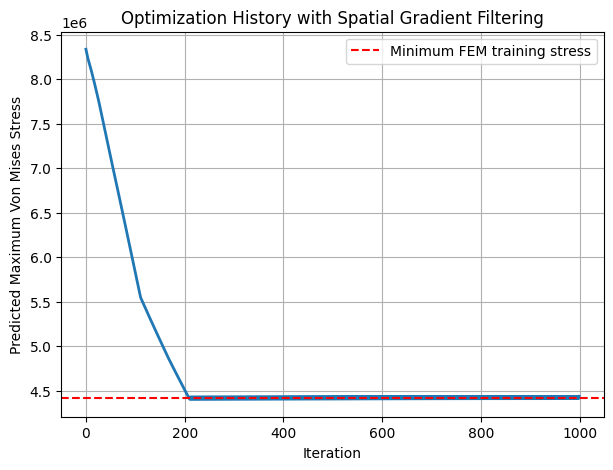

In [76]:
plt.figure(figsize=(7, 5))
plt.plot(stress_history, linewidth=2)
plt.axhline(np.min(y_train), color="red", linestyle="--", label="Minimum FEM training stress")
plt.xlabel("Iteration")
plt.ylabel("Predicted Maximum Von Mises Stress")
plt.title("Optimization History with Spatial Gradient Filtering")
plt.legend()
plt.grid(True)
plt.show()


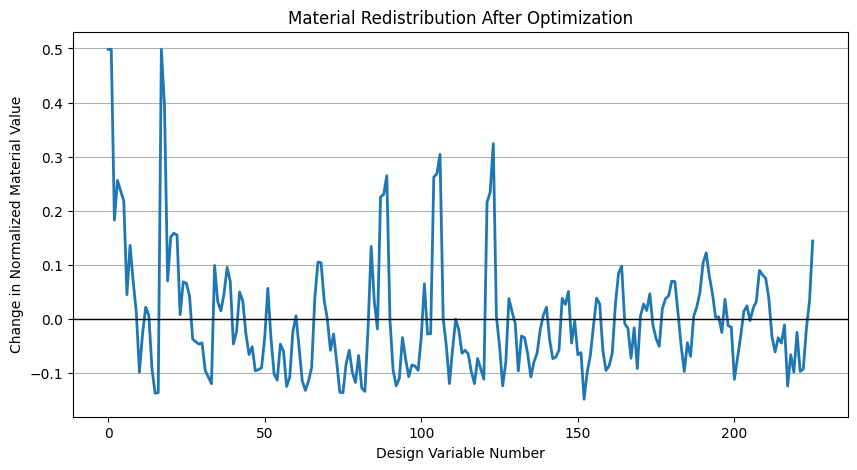

In [77]:
change = z_optimized.flatten() - z_init.flatten()

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(num_design_variables),
    change,
    linewidth=2
)

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Design Variable Number")
plt.ylabel("Change in Normalized Material Value")
plt.title("Material Redistribution After Optimization")
plt.grid(axis="y")
plt.show()
